<a href="https://colab.research.google.com/github/adelemak/Thesis-HSE-2026-Derivational-morphology-in-LLMs/blob/main/experiment%202/CLUSTERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Экспепримент 2. Кластеризация векторов

In [1]:
import os
import pandas as pd

EMBEDDINGS_DIR = "/content"

In [2]:
def safe_filename(text: str) -> str:
    return (
        str(text)
        .replace("/", "_")
        .replace("\\", "_")
        .strip()
    )

In [3]:
def make_qwen_embedding_path(verb: str) -> str:
    return os.path.join(EMBEDDINGS_DIR, f"{safe_filename(verb)}.npy")

def make_mistral_embedding_path(verb: str) -> str:
    return os.path.join(EMBEDDINGS_DIR, f"{safe_filename(verb)}_mistral.npy")

In [4]:
qwen_df = pd.read_csv('qwen.csv')
mistral_df = pd.read_csv('mistral.csv')

In [5]:
qwen_df["embedding_path"] = qwen_df["verb"].apply(make_qwen_embedding_path)
mistral_df["embedding_path"] = mistral_df["verb"].apply(make_mistral_embedding_path)

In [11]:
import numpy as np

def load_embedding_matrix(df):
    vectors = []
    for path in df["embedding_path"]:
        vec = np.load(path)
        vectors.append(vec)
    return np.vstack(vectors)

X_qwen = load_embedding_matrix(qwen_df)
X_mistral = load_embedding_matrix(mistral_df)

(X_qwen.shape)
print(X_mistral.shape)

(23, 5120)


In [12]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

sim_qwen = cosine_similarity(X_qwen)
sim_mistral = cosine_similarity(X_mistral)

sim_qwen_df = pd.DataFrame(sim_qwen, index=qwen_df["verb"], columns=qwen_df["verb"])
sim_mistral_df = pd.DataFrame(sim_mistral, index=mistral_df["verb"], columns=mistral_df["verb"])

sim_qwen_df.iloc[:5, :5]
sim_mistral_df.iloc[:5, :5]

verb,вертеть,выть,гнуть,дуть,опаздывать
verb,,,,,
вертеть,1.000000,0.875661,0.824464,0.824927,0.874524
выть,0.875661,1.000000,0.801183,0.815403,0.897461
гнуть,0.824464,0.801183,1.000000,0.895876,0.798512
дуть,0.824927,0.815403,0.895876,1.000000,0.769790
опаздывать,0.874524,0.897461,0.798512,0.769790,1.000000


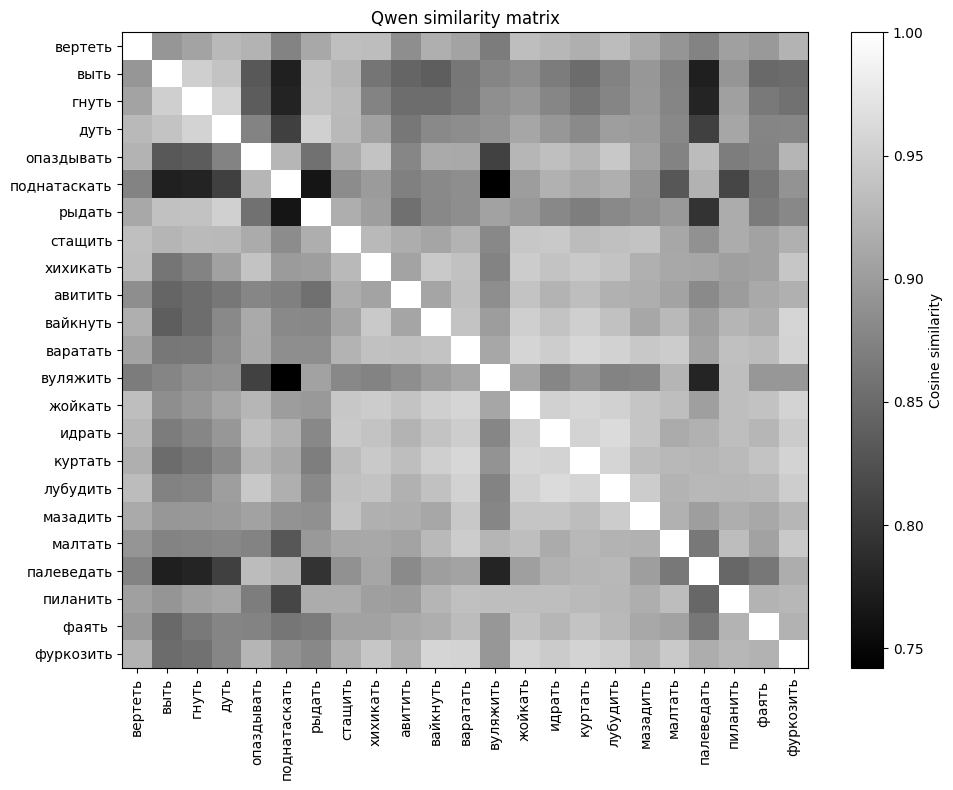

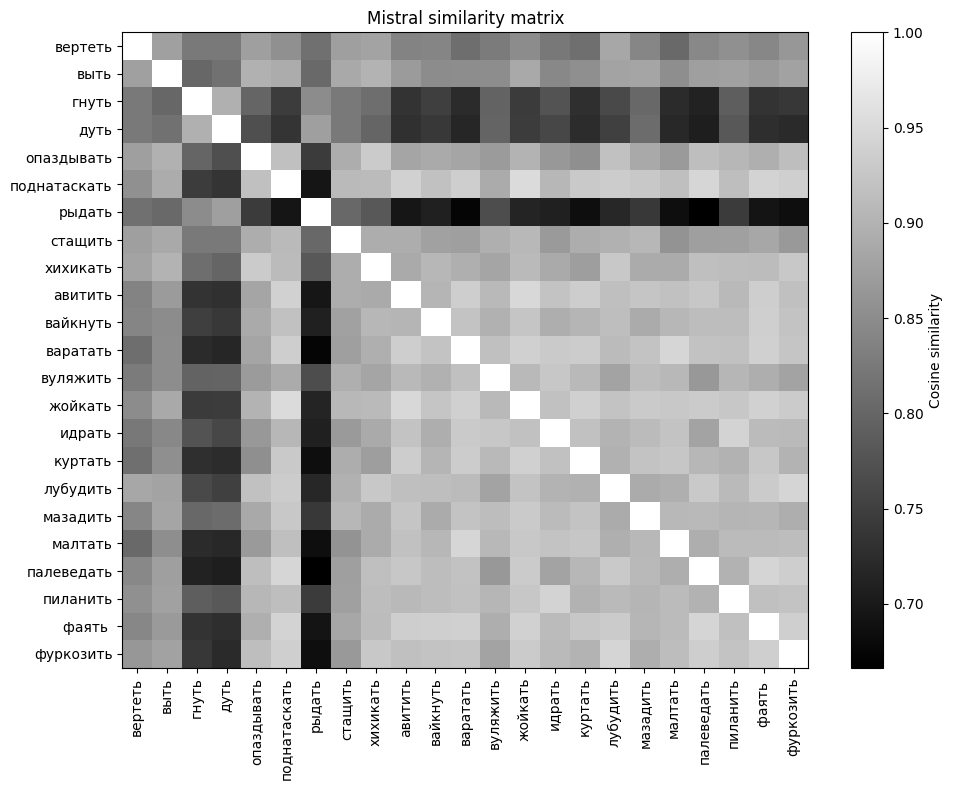

In [13]:
import matplotlib.pyplot as plt

def plot_similarity_heatmap(sim_df, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(sim_df.values, aspect="auto", cmap="gray")
    plt.colorbar(label="Cosine similarity")
    plt.xticks(range(len(sim_df.columns)), sim_df.columns, rotation=90)
    plt.yticks(range(len(sim_df.index)), sim_df.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_similarity_heatmap(sim_qwen_df, "Qwen similarity matrix")
plot_similarity_heatmap(sim_mistral_df, "Mistral similarity matrix")

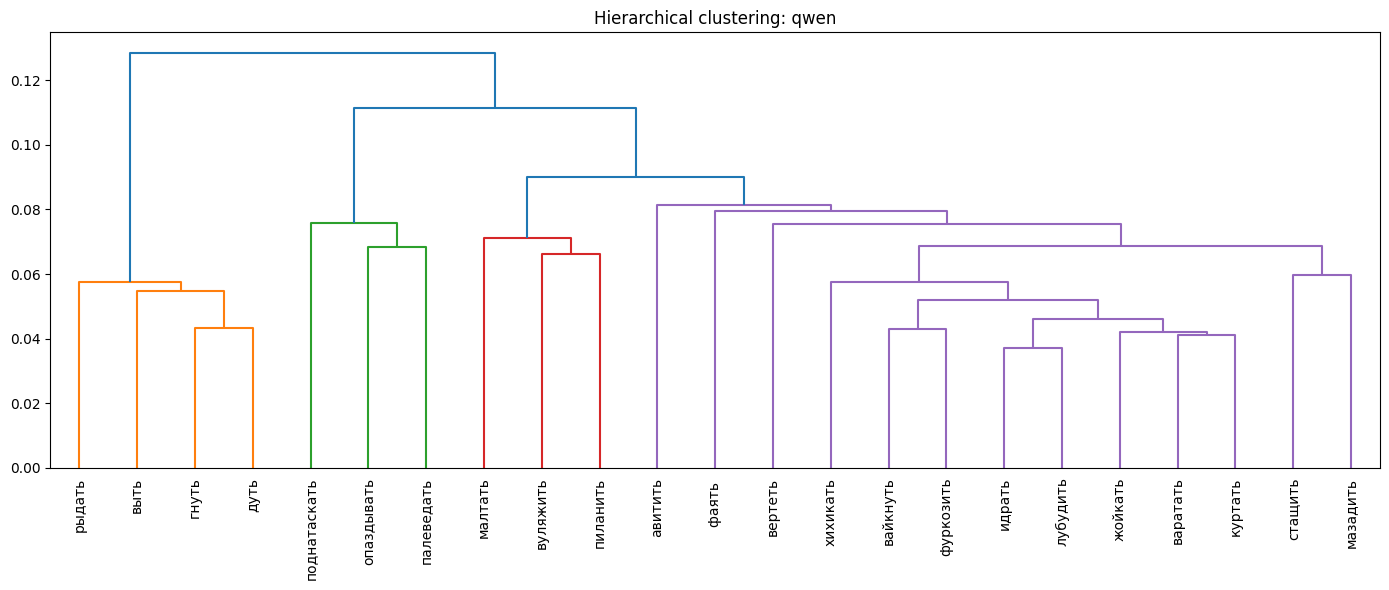

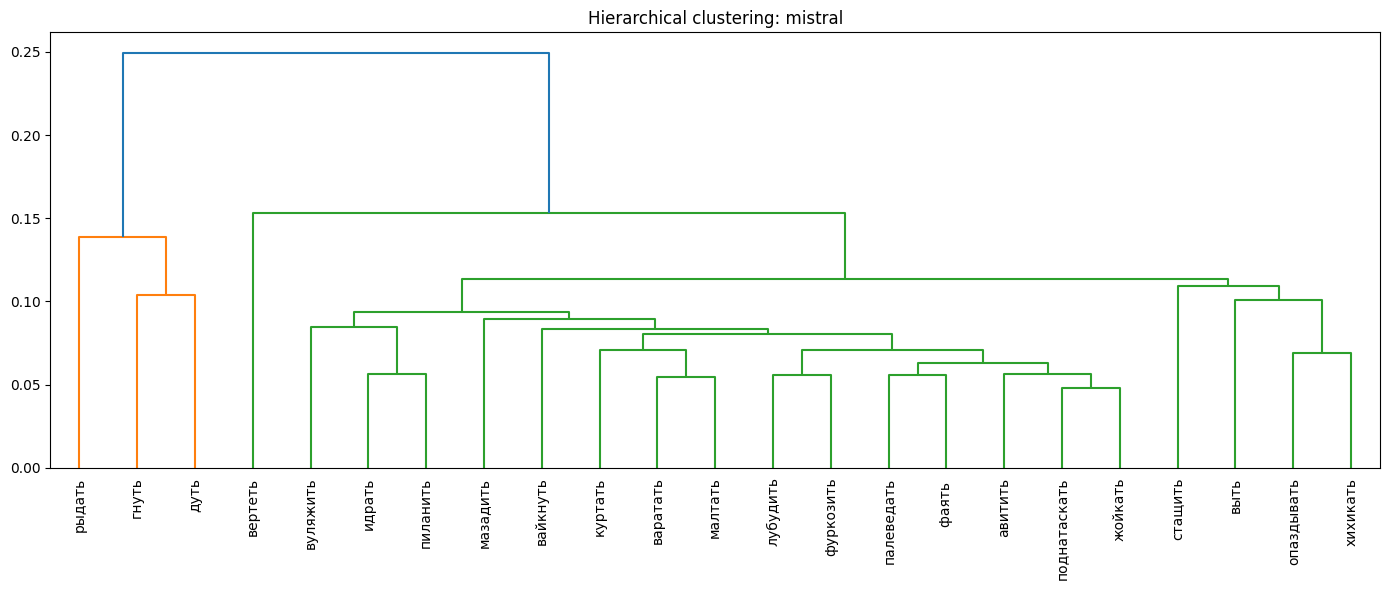

In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

def run_hierarchical_clustering(df, X, model_name, n_clusters=4):
    dist = pdist(X, metric="cosine")
    Z = linkage(dist, method="average")

    plt.figure(figsize=(14, 6))
    dendrogram(Z, labels=df["verb"].tolist(), leaf_rotation=90)
    plt.title(f"Hierarchical clustering: {model_name}")
    plt.tight_layout()
    plt.show()

    cluster_ids = fcluster(Z, t=n_clusters, criterion="maxclust")

    out = df.copy()
    out["cluster_id"] = cluster_ids
    return out, Z

qwen_clustered, Z_qwen = run_hierarchical_clustering(qwen_df, X_qwen, "qwen", n_clusters=4)
mistral_clustered, Z_mistral = run_hierarchical_clustering(mistral_df, X_mistral, "mistral", n_clusters=4)

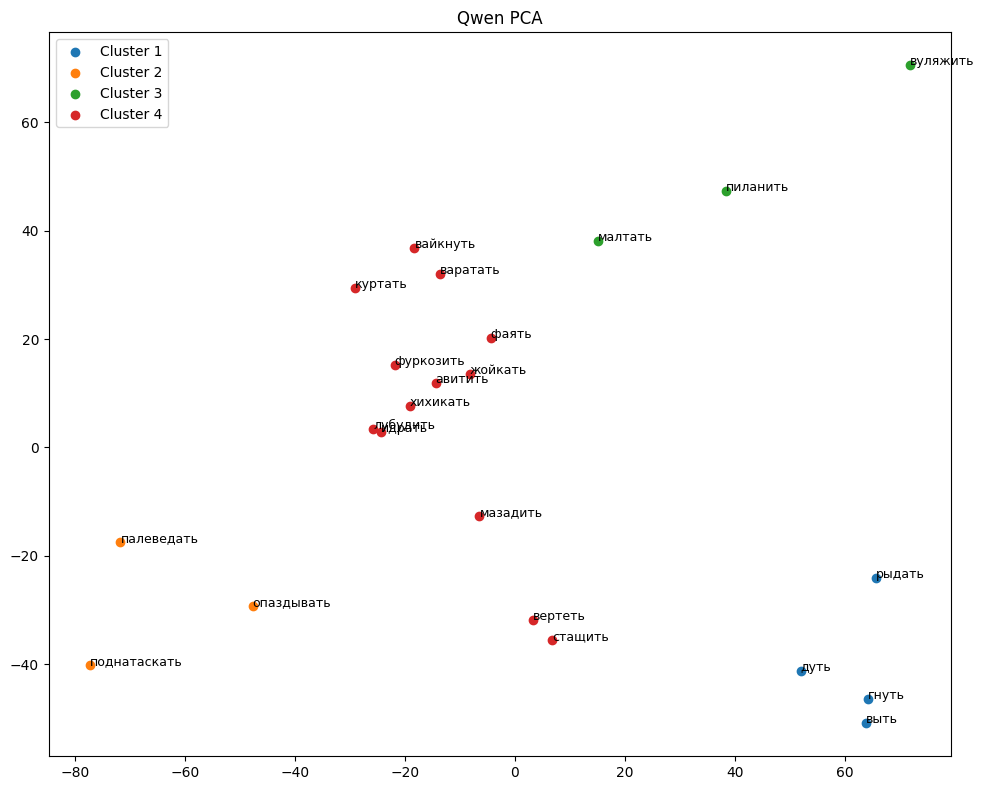

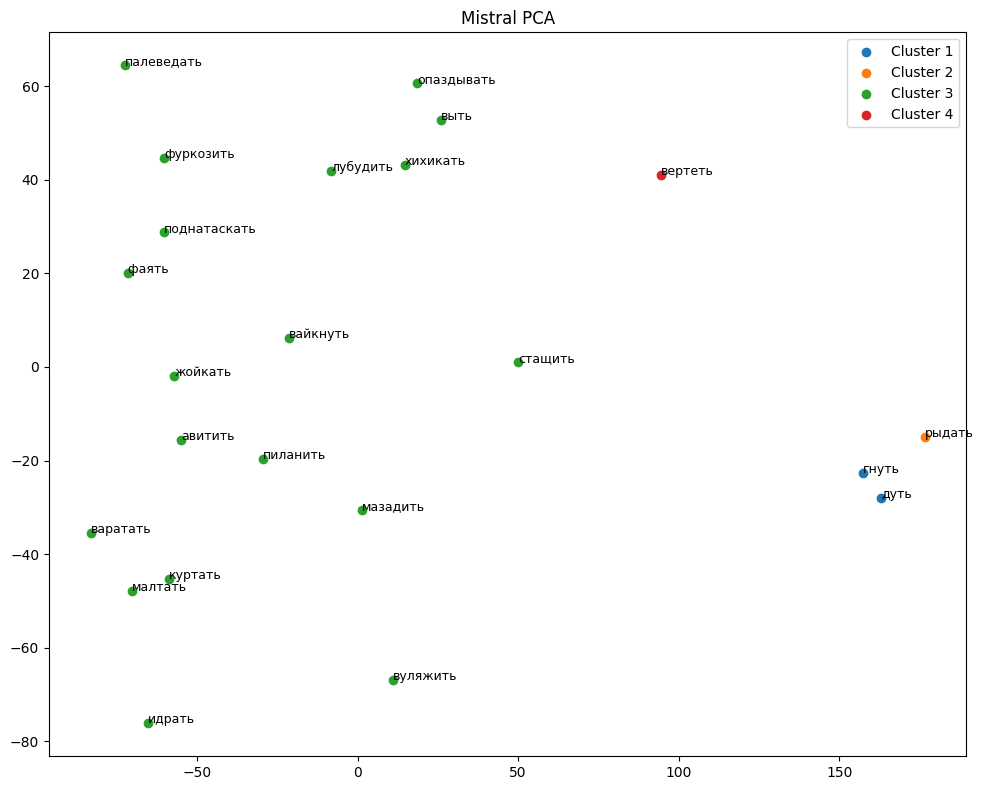

In [15]:
from sklearn.decomposition import PCA

def plot_pca(df, X, title):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(X)

    plot_df = df.copy()
    plot_df["x"] = coords[:, 0]
    plot_df["y"] = coords[:, 1]

    plt.figure(figsize=(10, 8))
    for cluster_id in sorted(plot_df["cluster_id"].unique()):
        sub = plot_df[plot_df["cluster_id"] == cluster_id]
        plt.scatter(sub["x"], sub["y"], label=f"Cluster {cluster_id}")
        for _, row in sub.iterrows():
            plt.text(row["x"], row["y"], row["verb"], fontsize=9)

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pca(qwen_clustered, X_qwen, "Qwen PCA")
plot_pca(mistral_clustered, X_mistral, "Mistral PCA")

In [16]:
def cluster_suffix_analysis(clustered_df):
    rows = []

    for cluster_id, sub in clustered_df.groupby("cluster_id"):
        suffix_counts = sub["suffix"].value_counts(dropna=False)
        dominant_suffix = suffix_counts.index[0]
        dominant_count = suffix_counts.iloc[0]
        dominant_share = dominant_count / len(sub)

        rows.append({
            "cluster_id": cluster_id,
            "n_items": len(sub),
            "n_distinct_suffixes": sub["suffix"].nunique(dropna=True),
            "dominant_suffix": dominant_suffix,
            "dominant_suffix_count": int(dominant_count),
            "dominant_suffix_share": round(dominant_share, 3),
            "verbs": "; ".join(sub["verb"].astype(str).tolist()),
            "suffixes": "; ".join(sub["suffix"].astype(str).tolist()),
        })

    return pd.DataFrame(rows).sort_values("cluster_id")

qwen_cluster_suffix = cluster_suffix_analysis(qwen_clustered)
mistral_cluster_suffix = cluster_suffix_analysis(mistral_clustered)
display(qwen_cluster_suffix)
display(mistral_cluster_suffix)

,cluster_id,n_items,n_distinct_suffixes,dominant_suffix,dominant_suffix_count,dominant_suffix_share,verbs,suffixes
0,1,4,3,другое,2,0.500,выть; гнуть; дуть; рыдать,другое; -арь; -щик (-чик); другое
1,2,3,2,-тель,2,0.667,опаздывать; поднатаскать; палеведать,-ун; -тель; -тель
2,3,3,3,"-ник (-еник, -ик)",1,0.333,вуляжить; малтать; пиланить,"-ник (-еник, -ик); -щик (-чик); -ист"
3,4,13,6,-ун,3,0.231,вертеть; стащить; хихикать; авитить; вайкнуть;...,-ун; -ер (-ор); -ун; -ер (-ор); -щик (-чик); -...


,cluster_id,n_items,n_distinct_suffixes,dominant_suffix,dominant_suffix_count,dominant_suffix_share,verbs,suffixes
0,1,2,1,другое,2,1.000,гнуть; дуть,другое; другое
1,2,1,1,другое,1,1.000,рыдать,другое
2,3,19,9,-тель,6,0.316,выть; опаздывать; поднатаскать; стащить; хихик...,другое; -ун; -тель; -тель; -тель; -тель; -щик ...
3,4,1,1,-льщик,1,1.000,вертеть,-льщик


In [17]:
def suffix_coherence_summary(cluster_suffix_df, model_name):
    return pd.DataFrame([{
        "model": model_name,
        "mean_dominant_suffix_share": cluster_suffix_df["dominant_suffix_share"].mean(),
        "mean_n_distinct_suffixes": cluster_suffix_df["n_distinct_suffixes"].mean(),
        "num_clusters": len(cluster_suffix_df),
    }])

embedding_summary = pd.concat([
    suffix_coherence_summary(qwen_cluster_suffix, "qwen"),
    suffix_coherence_summary(mistral_cluster_suffix, "mistral")
], ignore_index=True)

embedding_summary

,model,mean_dominant_suffix_share,mean_n_distinct_suffixes,num_clusters
0,qwen,0.43275,3.5,4
1,mistral,0.82900,3.0,4
